# シーズンの進み具合と実力差別の次の得点までの待ち時間（暫定勝ち点）

シーズン終了時の勝ち点は、試合の時点ではまだ分からない。そこで、試合開始時点の勝ち点（暫定勝ち点）から実力差を作る。

ただし、シーズン序盤は試合数が少ないので勝ち点の差が出にくい。また、リーグによって1シーズンの試合数が違う。そこで次のようにする。

1. シーズンの進み具合を「進捗率」（何試合目か ÷ そのシーズンの全試合数）で表し、8つに分ける
2. 実力差は1試合あたりの勝ち点（PPG）の差で表し、6つに分ける

比べるために、シーズン終了時のPPGの差でも同じことをする。

## 使う変数

- `home_provisional_points` / `away_provisional_points`：試合開始時点の勝ち点
- 進捗率 `progress` = 何試合目か ÷ そのシーズンの全試合数
- PPG = 暫定勝ち点 ÷ それまでの試合数（開幕戦は0で割ることになるので使わない）
- PPG差 = 自チームのPPG - 相手のPPG

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフの日本語が文字化けしないようにする
plt.rcParams["font.family"] = ["Hiragino Sans", "Noto Sans CJK JP", "Yu Gothic", "Meiryo", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

MEDIAN_COLOR = "#CC3311"
CENSOR_OPPONENT_COLOR = "#D62728"
CENSOR_MATCHEND_COLOR = "#1F77B4"


/Users/fujitaharukanin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. データの読み込み

`statsbomb_data` にある全リーグ・全シーズンの `*_goals_and_red_cards.csv` を読み込んで、1つの表にまとめる。

In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")
print(f"対象リーグ・シーズン: {sorted(df_all.groupby(['league_code','season_name']).size().index.tolist())}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461
対象リーグ・シーズン: [('FB', '2023/2024'), ('ISL', '2021/2022'), ('L1', '2015/2016'), ('LF', '2023/2024'), ('LL', '2015/2016'), ('PL', '2015/2016'), ('SA', '2015/2016'), ('WSL', '2018/2019'), ('WSL', '2019/2020'), ('WSL', '2020/2021'), ('WSL', '2023/2024')]


## 2. 進捗率とPPGを計算する

チームごとに試合を日付順に並べ、何試合目かを数えて、進捗率とPPGを出す。シーズン終了時のPPG（最終勝ち点 ÷ 全試合数）もここで計算しておく。
最後に試合ごとの表に戻して、PPG差を求める。

In [3]:
matches_meta = (
    df_all[["league_code", "season_name", "match_id", "match_date", "home_team", "away_team",
            "home_provisional_points", "away_provisional_points",
            "home_final_points", "away_final_points"]]
    .drop_duplicates(subset=["league_code", "season_name", "match_id"])
)

def _side_long(df, team_col, points_col, final_points_col, side):
    out = df.rename(columns={team_col: "team", points_col: "provisional_points",
                              final_points_col: "final_points"})[
        ["league_code", "season_name", "match_id", "match_date", "team",
         "provisional_points", "final_points"]
    ].copy()
    out["side"] = side
    return out

long_df = pd.concat([
    _side_long(matches_meta, "home_team", "home_provisional_points", "home_final_points", "home"),
    _side_long(matches_meta, "away_team", "away_provisional_points", "away_final_points", "away"),
], ignore_index=True)

long_df = long_df.sort_values(["league_code", "season_name", "team", "match_date", "match_id"], kind="mergesort")
long_df["team_match_number"] = long_df.groupby(["league_code", "season_name", "team"]).cumcount() + 1
long_df["team_total_matches"] = long_df.groupby(["league_code", "season_name", "team"])["team"].transform("size")
long_df["games_played_before"] = long_df["team_match_number"] - 1
long_df["progress"] = long_df["team_match_number"] / long_df["team_total_matches"]
long_df["ppg"] = long_df["provisional_points"] / long_df["games_played_before"].replace(0, np.nan)

# シーズン終了時のPPG（最終勝ち点 ÷ 全試合数）
long_df["final_ppg"] = long_df["final_points"] / long_df["team_total_matches"]

n_no_history = int((long_df["games_played_before"] == 0).sum())
print(f"開幕戦（games_played_before==0、ppg欠損）の観測数: {n_no_history} / {len(long_df)}")

wide = long_df.pivot_table(
    index=["league_code", "season_name", "match_id"], columns="side",
    values=["ppg", "progress", "final_ppg"], aggfunc="first",
)
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index()

wide["home_ppg_gap"] = wide["ppg_home"] - wide["ppg_away"]
wide["away_ppg_gap"] = -wide["home_ppg_gap"]

wide["home_final_ppg_gap"] = wide["final_ppg_home"] - wide["final_ppg_away"]
wide["away_final_ppg_gap"] = -wide["home_final_ppg_gap"]

progress_ppg = wide[["league_code", "season_name", "match_id",
                      "progress_home", "progress_away", "home_ppg_gap", "away_ppg_gap",
                      "home_final_ppg_gap", "away_final_ppg_gap"]]
progress_ppg.head()


開幕戦（games_played_before==0、ppg欠損）の観測数: 166 / 4922


,league_code,season_name,match_id,progress_home,progress_away,home_ppg_gap,away_ppg_gap,home_final_ppg_gap,away_final_ppg_gap
0,FB,2023/2024,3910730,0.045455,0.045455,NaN,NaN,-1.636364,1.636364
1,FB,2023/2024,3910731,0.045455,0.045455,NaN,NaN,1.363636,-1.363636
2,FB,2023/2024,3910732,0.045455,0.045455,NaN,NaN,-0.590909,0.590909
3,FB,2023/2024,3910733,0.045455,0.045455,NaN,NaN,-0.363636,0.363636
4,FB,2023/2024,3910734,0.045455,0.045455,NaN,NaN,1.000000,-1.000000


## 3. 進捗率を8つに分ける

0〜1を同じ幅で8つに分ける。

In [4]:
ROUND_N_BINS = 8
ROUND_EDGES = np.linspace(0.0, 1.0, ROUND_N_BINS + 1)
ROUND_ORDER = [f"{int(round(ROUND_EDGES[i] * 100))}〜{int(round(ROUND_EDGES[i + 1] * 100))}%"
               for i in range(ROUND_N_BINS)]

def classify_round(progress_values):
    return pd.cut(progress_values, bins=ROUND_EDGES, labels=ROUND_ORDER, include_lowest=True)

print("節（進捗率）8区分:")
for label in ROUND_ORDER:
    print(" -", label)


節（進捗率）8区分:
 - 0〜12%
 - 12〜25%
 - 25〜38%
 - 38〜50%
 - 50〜62%
 - 62〜75%
 - 75〜88%
 - 88〜100%


## 4. 実力差（暫定PPG差）を6つに分ける

全試合のホーム・アウェイ両方のPPG差を集め、`pd.qcut` で6分位に分ける。開幕戦は入れない。

In [5]:
SKILL_N_BINS = 6
pooled_ppg_gap = pd.concat([wide["home_ppg_gap"], wide["away_ppg_gap"]], ignore_index=True).dropna()

_, SKILL_GAP_EDGES = pd.qcut(pooled_ppg_gap, q=SKILL_N_BINS, retbins=True)

CATEGORY_ORDER = [
    f"{SKILL_GAP_EDGES[i]:+.2f}〜{SKILL_GAP_EDGES[i + 1]:+.2f}"
    for i in range(SKILL_N_BINS)
]

CLASSIFY_EDGES = SKILL_GAP_EDGES.copy()
CLASSIFY_EDGES[0] = -np.inf
CLASSIFY_EDGES[-1] = np.inf

print(f"実力差（PPG差）6区分の境界（n={len(pooled_ppg_gap)} のPPG差から算出、開幕戦は除く）:")
for label in CATEGORY_ORDER:
    print(" -", label)

def classify_skill_gap(values):
    return pd.cut(values, bins=CLASSIFY_EDGES, labels=CATEGORY_ORDER, include_lowest=True)


実力差（PPG差）6区分の境界（n=4754 のPPG差から算出、開幕戦は除く）:
 - -3.00〜-0.81
 - -0.81〜-0.33
 - -0.33〜+0.00
 - +0.00〜+0.33
 - +0.33〜+0.81
 - +0.81〜+3.00


## 4-2. 実力差（シーズン最終PPG差）を6つに分ける

比べるために、シーズン終了時のPPG差も同じように6つに分ける。

In [6]:
FINAL_SKILL_N_BINS = 6
pooled_final_ppg_gap = pd.concat(
    [wide["home_final_ppg_gap"], wide["away_final_ppg_gap"]], ignore_index=True
).dropna()

_, FINAL_SKILL_GAP_EDGES = pd.qcut(pooled_final_ppg_gap, q=FINAL_SKILL_N_BINS, retbins=True)

FINAL_CATEGORY_ORDER = [
    f"{FINAL_SKILL_GAP_EDGES[i]:+.2f}〜{FINAL_SKILL_GAP_EDGES[i + 1]:+.2f}"
    for i in range(FINAL_SKILL_N_BINS)
]

FINAL_CLASSIFY_EDGES = FINAL_SKILL_GAP_EDGES.copy()
FINAL_CLASSIFY_EDGES[0] = -np.inf
FINAL_CLASSIFY_EDGES[-1] = np.inf

print(f"実力差（シーズン最終PPG差）6区分の境界（n={len(pooled_final_ppg_gap)} から算出）:")
for label in FINAL_CATEGORY_ORDER:
    print(" -", label)

def classify_final_skill_gap(values):
    return pd.cut(values, bins=FINAL_CLASSIFY_EDGES, labels=FINAL_CATEGORY_ORDER, include_lowest=True)


実力差（シーズン最終PPG差）6区分の境界（n=4922 から算出）:
 - -2.63〜-0.73
 - -0.73〜-0.29
 - -0.29〜-0.00
 - -0.00〜+0.29
 - +0.29〜+0.73
 - +0.73〜+2.63


## 5. 生存時間データを作る

試合ごとに区間を作り、ホームとアウェイの観測を作る。進捗率と実力差は試合中変わらないので、観測にそのまま付ける。
開幕戦の観測は暫定PPG差の区分がないので、実力差ごとの集計には入らない。

In [7]:
def build_survival_events(df, progress_ppg_df):
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)
    group_cols = ["league_code", "season_name", "match_id"]
    goal_groups = {key: g.sort_values("time_min") for key, g in goal_rows.groupby(group_cols)}

    end_rows = df[df["red_card"].isna() & df["home_away"].isna() & df["end_time_minutes"].notna()].copy()
    end_rows["full_time_min"] = end_rows["end_time_minutes"].astype(float) + end_rows["end_time_second"].astype(float) / 60.0

    meta = progress_ppg_df.set_index(["league_code", "season_name", "match_id"])
    end_rows = end_rows.join(meta, on=["league_code", "season_name", "match_id"])

    end_rows["home_round"] = classify_round(end_rows["progress_home"])
    end_rows["away_round"] = classify_round(end_rows["progress_away"])
    end_rows["home_category"] = classify_skill_gap(end_rows["home_ppg_gap"])
    end_rows["away_category"] = classify_skill_gap(end_rows["away_ppg_gap"])
    end_rows["home_final_category"] = classify_final_skill_gap(end_rows["home_final_ppg_gap"])
    end_rows["away_final_category"] = classify_final_skill_gap(end_rows["away_final_ppg_gap"])

    records = []
    for row in end_rows.itertuples(index=False):
        key = (row.league_code, row.season_name, row.match_id)
        full_time = row.full_time_min
        meta_out = dict(league_code=row.league_code, season_name=row.season_name, match_id=row.match_id)

        g = goal_groups.get(key)
        if g is None:
            times = np.array([])
            sides = np.array([], dtype=int)
        else:
            times = g["time_min"].to_numpy()
            sides = g["home_away"].to_numpy()

        prev_t = 0.0
        boundaries = list(times) + [full_time]
        for i, t in enumerate(boundaries):
            duration = t - prev_t
            is_last = (i == len(times))

            if not is_last:
                scorer = int(sides[i])
                if scorer == 0:
                    records.append({**meta_out, "team": "home", "category": row.home_category,
                                     "final_category": row.home_final_category, "round_bin": row.home_round,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta_out, "team": "away", "category": row.away_category,
                                     "final_category": row.away_final_category, "round_bin": row.away_round,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
                else:
                    records.append({**meta_out, "team": "away", "category": row.away_category,
                                     "final_category": row.away_final_category, "round_bin": row.away_round,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta_out, "team": "home", "category": row.home_category,
                                     "final_category": row.home_final_category, "round_bin": row.home_round,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
            else:
                records.append({**meta_out, "team": "home", "category": row.home_category,
                                 "final_category": row.home_final_category, "round_bin": row.home_round,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})
                records.append({**meta_out, "team": "away", "category": row.away_category,
                                 "final_category": row.away_final_category, "round_bin": row.away_round,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})

            prev_t = t

    return pd.DataFrame(records)


survival_df = build_survival_events(df_all, progress_ppg)
n_event = int((survival_df["event"] == 1).sum())
n_cens_opp = int((survival_df["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df["censor_type"] == "match_end").sum())
n_no_cat = int(survival_df["category"].isna().sum())
print(f"観測数: {len(survival_df)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")
print(f"実力差区分が欠損（開幕戦）の観測数: {n_no_cat}")

survival_df.groupby(["round_bin", "category"], observed=True).size().unstack(fill_value=0).reindex(
    index=ROUND_ORDER, columns=CATEGORY_ORDER)


観測数: 18850（イベント: 6964, 相手の得点による打ち切り: 6964, 試合終了による打ち切り: 4922）
実力差区分が欠損（開幕戦）の観測数: 584


category,-3.00〜-0.81,-0.81〜-0.33,-0.33〜+0.00,+0.00〜+0.33,+0.33〜+0.81,+0.81〜+3.00
round_bin,,,,,,
0〜12%,364,98,323,0,98,370
12〜25%,561,440,399,182,411,566
25〜38%,434,441,345,348,415,431
38〜50%,467,439,355,306,402,487
50〜62%,323,318,370,330,329,314
62〜75%,392,398,503,407,401,378
75〜88%,381,391,470,415,401,414
88〜100%,419,504,458,418,469,381


## 6. Kaplan-Meier曲線を当てはめる

進捗率8区分 × 実力差6区分の組み合わせごとに、Kaplan-Meier曲線を求める。

In [8]:
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。カーネルを再起動してから、このセルより上から再実行してください。"
    )

km_fits = {rb: {} for rb in ROUND_ORDER}
summary_rows = []

for rb in ROUND_ORDER:
    for cat in CATEGORY_ORDER:
        sub = survival_df[(survival_df["round_bin"] == rb) & (survival_df["category"] == cat)]
        n = len(sub)
        if n == 0:
            km_fits[rb][cat] = None
            summary_rows.append({"節区分": rb, "実力差区分": cat, "n": 0, "イベント数": 0,
                                  "生存時間中央値me(分)": np.nan})
            continue
        n_event = int((sub["event"] == 1).sum())
        kmf = KaplanMeierFitter()
        kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"{cat} (n={n})")
        km_fits[rb][cat] = kmf
        summary_rows.append({"節区分": rb, "実力差区分": cat, "n": n, "イベント数": n_event,
                              "生存時間中央値me(分)": kmf.median_survival_time_})

km_summary = pd.DataFrame(summary_rows).set_index(["節区分", "実力差区分"]).reindex(
    pd.MultiIndex.from_product([ROUND_ORDER, CATEGORY_ORDER], names=["節区分", "実力差区分"]))
km_summary


n  イベント数  生存時間中央値me(分)
節区分     実力差区分                                
0〜12%   -3.00〜-0.81  364    106     61.566667
        -0.81〜-0.33   98     35     53.983333
        -0.33〜+0.00  323    117     50.950000
        +0.00〜+0.33    0      0           NaN
        +0.33〜+0.81   98     33     50.816667
        +0.81〜+3.00  370    173     34.200000
12〜25%  -3.00〜-0.81  561    145     58.400000
        -0.81〜-0.33  440    143     52.683333
        -0.33〜+0.00  399    141     47.883333
        +0.00〜+0.33  182     70     46.766667
        +0.33〜+0.81  411    173     37.450000
        +0.81〜+3.00  566    281     31.150000
25〜38%  -3.00〜-0.81  434     86     77.300000
        -0.81〜-0.33  441    142     56.133333
        -0.33〜+0.00  345    124     47.533333
        +0.00〜+0.33  348    124     45.950000
        +0.33〜+0.81  415    171     46.450000
        +0.81〜+3.00  431    239     28.116667
38〜50%  -3.00〜-0.81  467     87     65.683333
        -0.81〜-0.33  439    124     70.900000
        -0.33〜+0.00  355    110     56.166667
        +0.00〜+0.33  306    117     54.933333
        +0.33〜+0.81  402    177     42.150000
        +0.81〜+3.00  487    288     25.150000
50〜62%  -3.00〜-0.81  323     54           inf
        -0.81〜-0.33  318     95     57.683333
        -0.33〜+0.00  370    141     50.183333
        +0.00〜+0.33  330    116     52.916667
        +0.33〜+0.81  329    140     41.816667
        +0.81〜+3.00  314    181     27.833333
62〜75%  -3.00〜-0.81  392     65     77.566667
        -0.81〜-0.33  398    110     53.900000
        -0.33〜+0.00  503    172     48.133333
        +0.00〜+0.33  407    154     51.183333
        +0.33〜+0.81  401    188     40.133333
        +0.81〜+3.00  378    230     24.266667
75〜88%  -3.00〜-0.81  381     52           inf
        -0.81〜-0.33  391    116     56.783333
        -0.33〜+0.00  470    164     42.933333
        +0.00〜+0.33  415    164     43.316667
        +0.33〜+0.81  401    175     46.350000
        +0.81〜+3.00  414    258     24.133333
88〜100% -3.00〜-0.81  419     59           inf
        -0.81〜-0.33  504    150     53.150000
        -0.33〜+0.00  458    162     47.966667
        +0.00〜+0.33  418    153     54.500000
        +0.33〜+0.81  469    207     35.916667
        +0.81〜+3.00  381    244     23.666667

## 7. 進捗率ごとのKaplan-Meier曲線

進捗率の区分ごとに1枚ずつ、実力差6区分の曲線を重ねて描く。格上ほど赤、格下ほど青にする。

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

保存しました: ./figures/survival_provisional_point_gap_km_grid.png


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

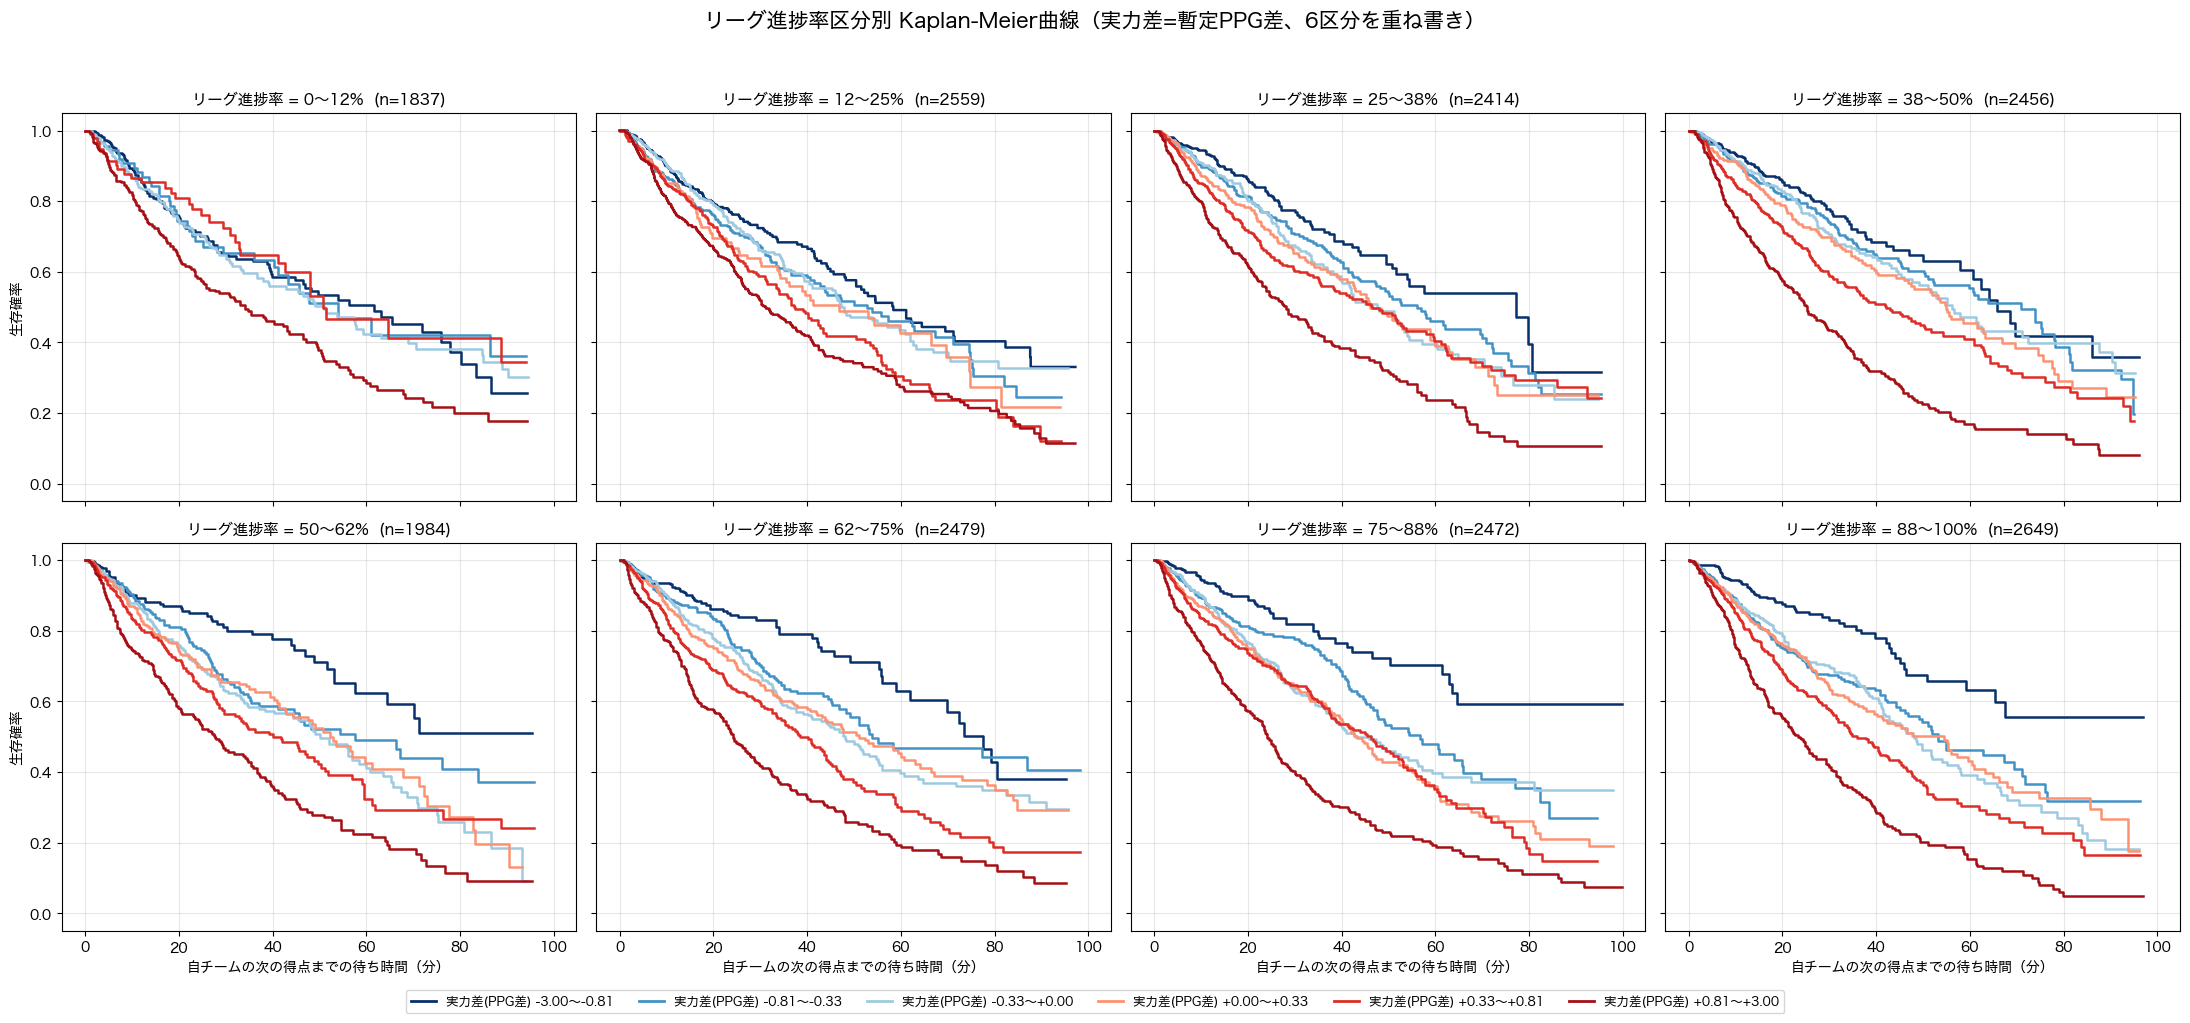

In [9]:
# 格下ほど青、格上ほど赤（CATEGORY_ORDER はPPG差の小さい順）
DIVERGING_COLORS = [
    "#08306B",  # 濃い青（格下）
    "#4292C6",  # 中間の青
    "#9ECAE1",  # 薄い青
    "#FC9272",  # 薄い赤
    "#DE2D26",  # 中間の赤
    "#A50F15",  # 濃い赤（格上）
]
assert len(DIVERGING_COLORS) == len(CATEGORY_ORDER)
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, DIVERGING_COLORS))

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, rb in enumerate(ROUND_ORDER):
    ax = axes[i]
    n_total = len(survival_df[survival_df["round_bin"] == rb])
    for cat in CATEGORY_ORDER:
        kmf = km_fits[rb][cat]
        if kmf is None:
            continue
        kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                    color=CATEGORY_COLORS[cat], linewidth=1.8, legend=False)
    ax.set_title(f"リーグ進捗率 = {rb}  (n={n_total})", fontsize=11)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

legend_handles = [Line2D([], [], color=CATEGORY_COLORS[cat], linewidth=2, label=f"実力差(PPG差) {cat}")
                   for cat in CATEGORY_ORDER]
fig.legend(handles=legend_handles, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("リーグ進捗率区分別 Kaplan-Meier曲線（実力差=暫定PPG差、6区分を重ね書き）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_provisional_point_gap_km_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


## 6-2. シーズン最終PPG差で当てはめる

6と同じことを、実力差をシーズン最終PPG差に変えて行う。

In [10]:
km_fits_final = {rb: {} for rb in ROUND_ORDER}
final_summary_rows = []

for rb in ROUND_ORDER:
    for cat in FINAL_CATEGORY_ORDER:
        sub = survival_df[(survival_df["round_bin"] == rb) & (survival_df["final_category"] == cat)]
        n = len(sub)
        if n == 0:
            km_fits_final[rb][cat] = None
            final_summary_rows.append({"節区分": rb, "実力差区分(最終PPG差)": cat, "n": 0, "イベント数": 0,
                                        "生存時間中央値me(分)": np.nan})
            continue
        n_event = int((sub["event"] == 1).sum())
        kmf = KaplanMeierFitter()
        kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"{cat} (n={n})")
        km_fits_final[rb][cat] = kmf
        final_summary_rows.append({"節区分": rb, "実力差区分(最終PPG差)": cat, "n": n, "イベント数": n_event,
                                    "生存時間中央値me(分)": kmf.median_survival_time_})

final_km_summary = pd.DataFrame(final_summary_rows).set_index(["節区分", "実力差区分(最終PPG差)"]).reindex(
    pd.MultiIndex.from_product([ROUND_ORDER, FINAL_CATEGORY_ORDER], names=["節区分", "実力差区分(最終PPG差)"]))
final_km_summary


n  イベント数  生存時間中央値me(分)
節区分     実力差区分(最終PPG差)                          
0〜12%   -2.63〜-0.73    334     44           inf
        -0.73〜-0.29    315     85     57.766667
        -0.29〜-0.00    270     79     74.100000
        -0.00〜+0.29    270    112     47.516667
        +0.29〜+0.73    322    146     38.700000
        +0.73〜+2.63    326    206     24.433333
12〜25%  -2.63〜-0.73    454     78     82.333333
        -0.73〜-0.29    418    101     75.466667
        -0.29〜-0.00    422    152     46.100000
        -0.00〜+0.29    416    159     42.383333
        +0.29〜+0.73    384    192     34.016667
        +0.73〜+2.63    465    271     26.816667
25〜38%  -2.63〜-0.73    439     66     82.000000
        -0.73〜-0.29    360     91     70.366667
        -0.29〜-0.00    409    129     56.133333
        -0.00〜+0.29    396    158     47.283333
        +0.29〜+0.73    352    162     38.316667
        +0.73〜+2.63    458    280     24.116667
38〜50%  -2.63〜-0.73    505     81     85.983333
        -0.73〜-0.29    373    103     69.616667
        -0.29〜-0.00    362    113     55.616667
        -0.00〜+0.29    352    138     54.283333
        +0.29〜+0.73    359    156     46.816667
        +0.73〜+2.63    505    312     25.150000
50〜62%  -2.63〜-0.73    351     54           inf
        -0.73〜-0.29    336     89     70.116667
        -0.29〜-0.00    313    115     49.033333
        -0.00〜+0.29    307    116     45.716667
        +0.29〜+0.73    328    144     48.450000
        +0.73〜+2.63    349    209     26.150000
62〜75%  -2.63〜-0.73    482     73     77.566667
        -0.73〜-0.29    378    101     60.666667
        -0.29〜-0.00    398    121     55.400000
        -0.00〜+0.29    378    150     50.016667
        +0.29〜+0.73    380    183     38.400000
        +0.73〜+2.63    463    291     23.583333
75〜88%  -2.63〜-0.73    434     53           inf
        -0.73〜-0.29    380    104     56.783333
        -0.29〜-0.00    392    129     48.900000
        -0.00〜+0.29    426    174     42.066667
        +0.29〜+0.73    377    174     40.233333
        +0.73〜+2.63    463    295     24.866667
88〜100% -2.63〜-0.73    506     71           inf
        -0.73〜-0.29    440    128     54.850000
        -0.29〜-0.00    445    152     51.050000
        -0.00〜+0.29    399    154     45.250000
        +0.29〜+0.73    398    177     38.183333
        +0.73〜+2.63    461    293     23.666667

## 7-2. 進捗率ごとのKaplan-Meier曲線（シーズン最終PPG差）

7と同じ色の付け方で描く。

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

保存しました: ./figures/survival_final_ppg_gap_km_grid.png


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

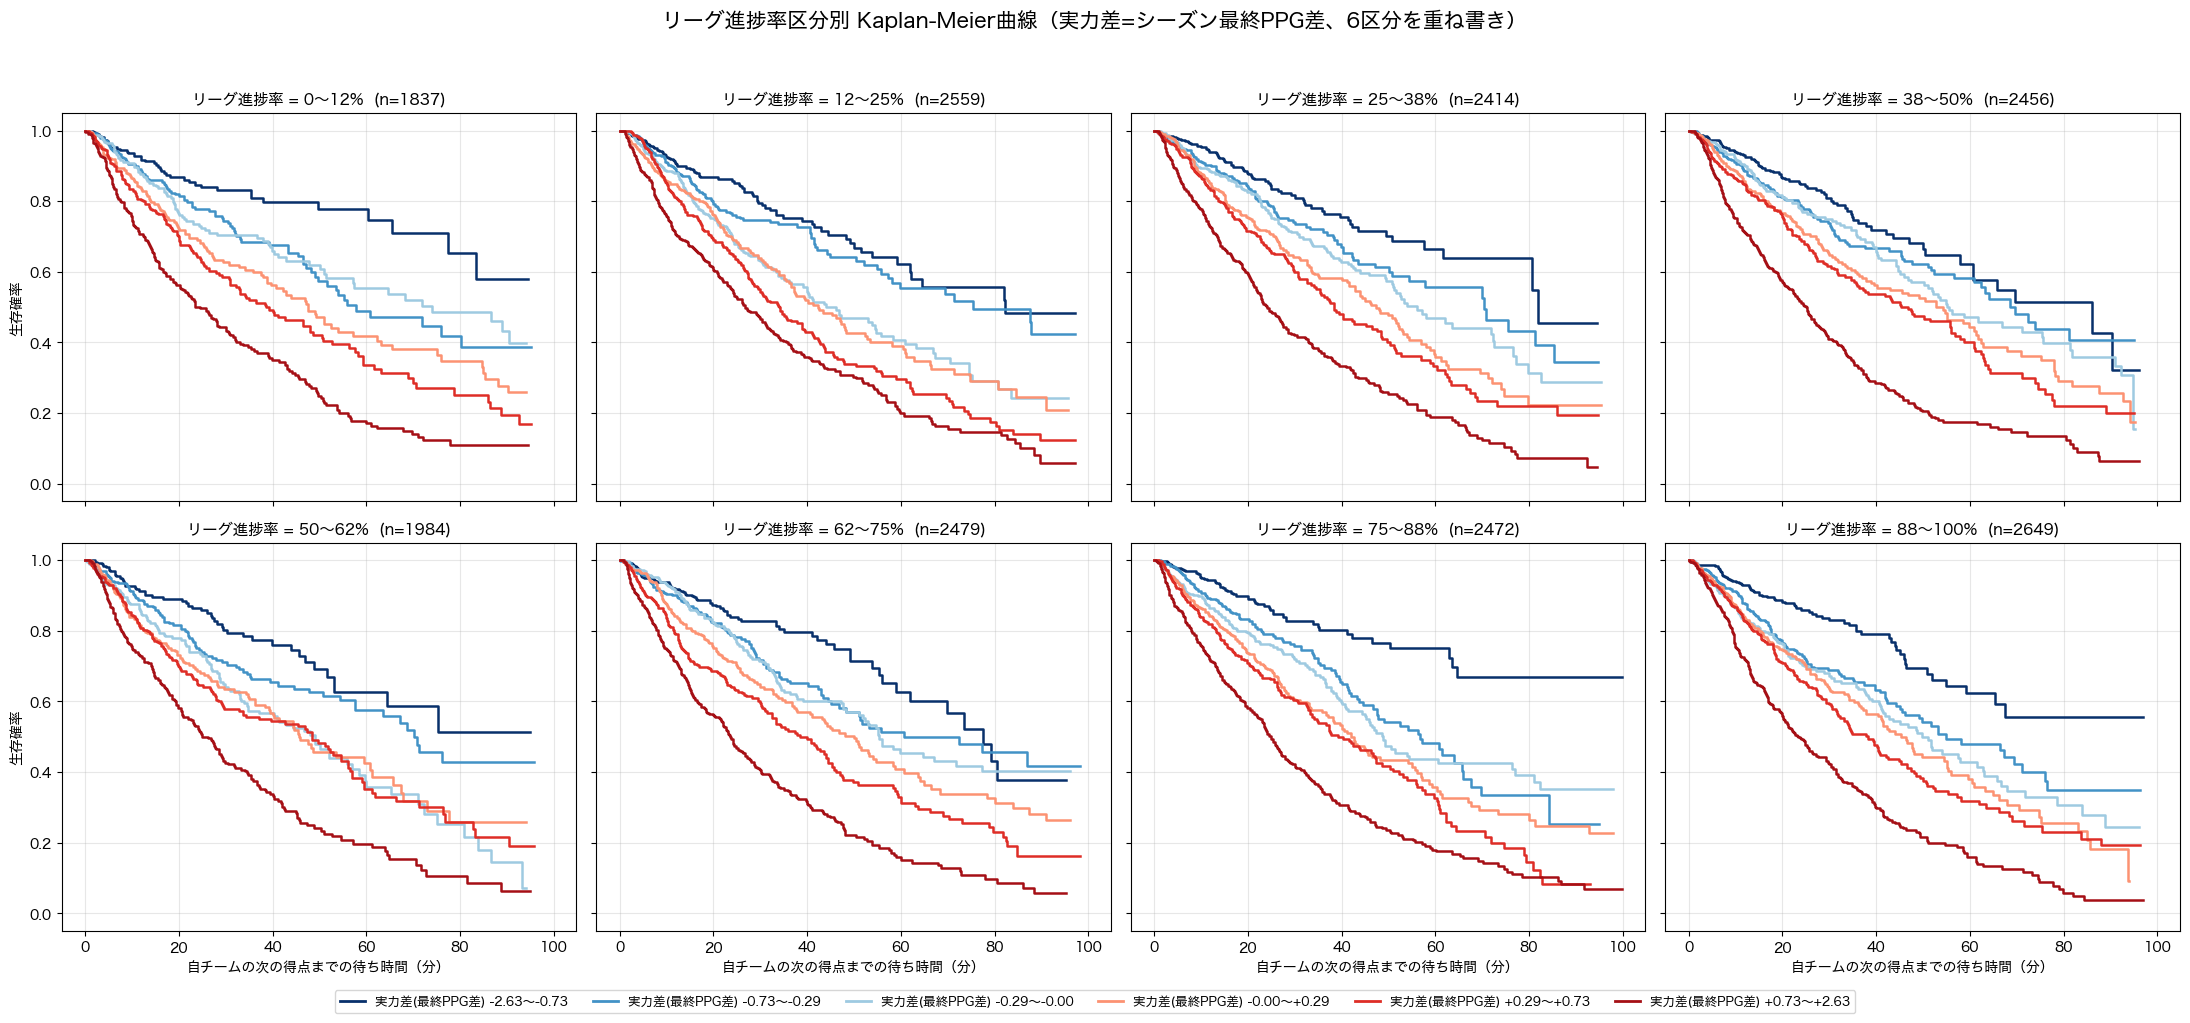

In [11]:
FINAL_CATEGORY_COLORS = dict(zip(FINAL_CATEGORY_ORDER, DIVERGING_COLORS))

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, rb in enumerate(ROUND_ORDER):
    ax = axes[i]
    n_total = len(survival_df[survival_df["round_bin"] == rb])
    for cat in FINAL_CATEGORY_ORDER:
        kmf = km_fits_final[rb][cat]
        if kmf is None:
            continue
        kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                    color=FINAL_CATEGORY_COLORS[cat], linewidth=1.8, legend=False)
    ax.set_title(f"リーグ進捗率 = {rb}  (n={n_total})", fontsize=11)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

legend_handles = [Line2D([], [], color=FINAL_CATEGORY_COLORS[cat], linewidth=2, label=f"実力差(最終PPG差) {cat}")
                   for cat in FINAL_CATEGORY_ORDER]
fig.legend(handles=legend_handles, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.03))

fig.suptitle("リーグ進捗率区分別 Kaplan-Meier曲線（実力差=シーズン最終PPG差、6区分を重ね書き）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_final_ppg_gap_km_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


## 8. 進捗率ごとのログランク検定

進捗率の区分ごとに、実力差6区分をまとめて比べる。

In [12]:
logrank_rows = []
for rb in ROUND_ORDER:
    sub = survival_df[(survival_df["round_bin"] == rb) & survival_df["category"].notna()]
    present_cats = sub["category"].nunique()
    if len(sub) == 0 or present_cats < 2:
        logrank_rows.append({"節区分": rb, "n": len(sub), "区分数": present_cats,
                              "検定統計量": np.nan, "自由度": np.nan, "p値": np.nan})
        continue
    result = multivariate_logrank_test(
        event_durations=sub["waiting_time"], groups=sub["category"], event_observed=sub["event"],
    )
    logrank_rows.append({"節区分": rb, "n": len(sub), "区分数": present_cats,
                          "検定統計量": result.test_statistic, "自由度": result.degrees_of_freedom,
                          "p値": result.p_value})

logrank_summary = pd.DataFrame(logrank_rows).set_index("節区分").reindex(ROUND_ORDER)

def stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

logrank_summary["有意水準"] = logrank_summary["p値"].apply(stars)
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01（打ち切りを考慮したログランク検定、区分間の多重比較検定）")
logrank_summary


有意水準: * p<0.10, ** p<0.05, *** p<0.01（打ち切りを考慮したログランク検定、区分間の多重比較検定）


,n,区分数,検定統計量,自由度,p値,有意水準
節区分,,,,,,
0〜12%,1253,5,23.551178,4,9.824434e-05,***
12〜25%,2559,6,54.772543,5,1.453850e-10,***
25〜38%,2414,6,94.410142,5,7.946404e-19,***
38〜50%,2456,6,176.831188,5,2.541554e-36,***
50〜62%,1984,6,88.677442,5,1.273751e-17,***
62〜75%,2479,6,141.943060,5,6.911818e-29,***
75〜88%,2472,6,165.299430,5,7.341224e-34,***
88〜100%,2649,6,172.245088,5,2.421227e-35,***


## 9. 進捗率ごとに2区分ずつ比べる

進捗率の区分ごとに、実力差の区分を2つずつ比べる（15通り）。Bonferroni補正は、進捗率の区分の中の15通りで行う。

In [13]:
from lifelines.statistics import pairwise_logrank_test


def pairwise_logrank_table(round_bin_label):
    sub = survival_df[(survival_df["round_bin"] == round_bin_label) & survival_df["category"].notna()]
    result = pairwise_logrank_test(
        event_durations=sub["waiting_time"], groups=sub["category"], event_observed=sub["event"],
    )
    table = result.summary.copy()
    n_comparisons = len(table)
    table["p_bonferroni"] = (table["p"] * n_comparisons).clip(upper=1.0)
    table = table.sort_values("p")
    table["p"] = table["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
    table["p_bonferroni"] = table["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")
    print(f"節（進捗率）= {round_bin_label}  (n={len(sub)}, 比較数={n_comparisons})")
    return table


def plot_km_single(round_bin_label):
    """進捗率の区分1つぶんのKaplan-Meier曲線を1枚で描く"""
    fig, ax = plt.subplots(figsize=(11, 7))
    n_total = len(survival_df[survival_df["round_bin"] == round_bin_label])
    for cat in CATEGORY_ORDER:
        kmf = km_fits[round_bin_label][cat]
        if kmf is None:
            continue
        kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                    color=CATEGORY_COLORS[cat], linewidth=2.2, legend=False)
    ax.set_title(f"リーグ進捗率 = {round_bin_label}  (n={n_total})", fontsize=14)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

    legend_handles = [Line2D([], [], color=CATEGORY_COLORS[cat], linewidth=2.2, label=f"実力差(PPG差) {cat}")
                       for cat in CATEGORY_ORDER]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper right", title="実力差(PPG差)")
    fig.tight_layout()
    plt.show()


### 進捗率 0〜12%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

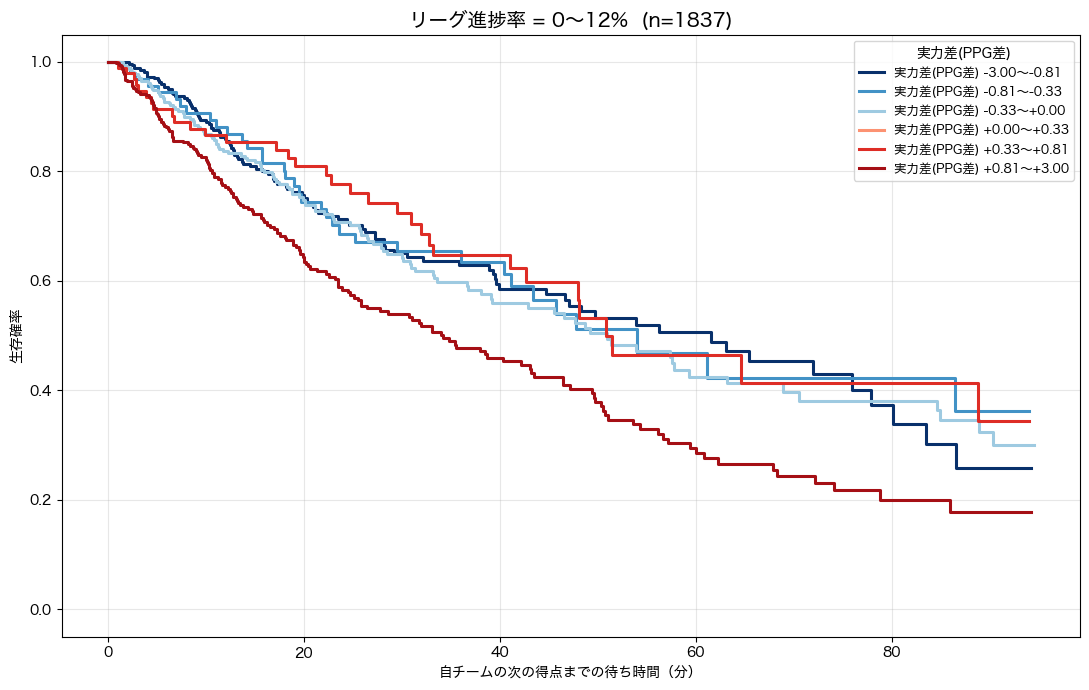

節（進捗率）= 0〜12%  (n=1253, 比較数=10)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81       15.278728  9.275518e-05***  13.396213   
            -0.33〜+0.00       10.917164  9.527735e-04***  10.035579   
+0.33〜+0.81 +0.81〜+3.00        7.918122  4.894206e-03***   7.674710   
+0.81〜+3.00 -0.81〜-0.33        6.666405  9.824715e-03***   6.669369   
+0.33〜+0.81 -0.33〜+0.00        0.550517     4.581064e-01   1.126245   
-0.33〜+0.00 -3.00〜-0.81        0.258580     6.110973e-01   0.710526   
            -0.81〜-0.33        0.224788     6.354158e-01   0.654227   
+0.33〜+0.81 -3.00〜-0.81        0.197585     6.566769e-01   0.606744   
            -0.81〜-0.33        0.058824     8.083652e-01   0.306921   
-0.81〜-0.33 -3.00〜-0.81        0.033953     8.538069e-01   0.228018   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  9.275518e-04***  
            -0.33〜+0.00  9.527735e-03***  
+0.33〜+0.81 +0.81〜+3.00   4.894206e-02**  
+0.81〜+3.00 -0.81〜-0.33    9.824715e-02*  
+0.33〜+0.81 -0.33〜+0.00     1.000000e+00  
-0.33〜+0.00 -3.00〜-0.81     1.000000e+00  
            -0.81〜-0.33     1.000000e+00  
+0.33〜+0.81 -3.00〜-0.81     1.000000e+00  
            -0.81〜-0.33     1.000000e+00  
-0.81〜-0.33 -3.00〜-0.81     1.000000e+00

In [14]:
plot_km_single("0〜12%")

pairwise_logrank_table("0〜12%")

### 進捗率 12〜25%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

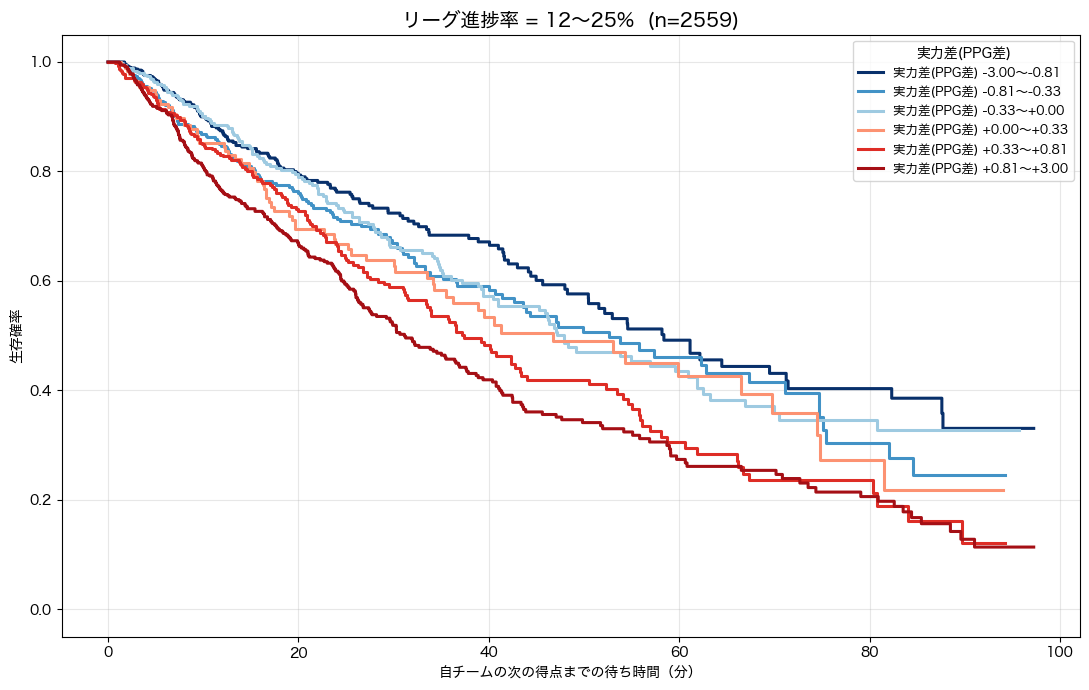

節（進捗率）= 12〜25%  (n=2559, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81       41.567803  1.138529e-10***  33.032110   
            -0.33〜+0.00       23.097975  1.539527e-06***  19.309081   
+0.33〜+0.81 -3.00〜-0.81       19.220710  1.164433e-05***  16.390013   
+0.81〜+3.00 -0.81〜-0.33       17.000535  3.736929e-05***  14.707787   
+0.33〜+0.81 -0.33〜+0.00        8.850507  2.930074e-03***   8.414847   
+0.00〜+0.33 +0.81〜+3.00        5.762635   1.637050e-02**   5.932758   
+0.33〜+0.81 -0.81〜-0.33        5.738221   1.659959e-02**   5.912708   
+0.00〜+0.33 -3.00〜-0.81        4.843567   2.774944e-02**   5.171398   
-0.81〜-0.33 -3.00〜-0.81        3.580573    5.845897e-02*   4.096432   
+0.33〜+0.81 +0.81〜+3.00        2.596678     1.070880e-01   3.223131   
-0.33〜+0.00 -3.00〜-0.81        1.519977     2.176230e-01   2.200097   
+0.00〜+0.33 +0.33〜+0.81        1.466630     2.258782e-01   2.146383   
            -0.33〜+0.00        1.179668     2.774236e-01   1.849838   
            -0.81〜-0.33        0.548570     4.589027e-01   1.123740   
-0.33〜+0.00 -0.81〜-0.33        0.291093     5.895212e-01   0.762385   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  1.707794e-09***  
            -0.33〜+0.00  2.309291e-05***  
+0.33〜+0.81 -3.00〜-0.81  1.746649e-04***  
+0.81〜+3.00 -0.81〜-0.33  5.605394e-04***  
+0.33〜+0.81 -0.33〜+0.00   4.395112e-02**  
+0.00〜+0.33 +0.81〜+3.00     2.455575e-01  
+0.33〜+0.81 -0.81〜-0.33     2.489939e-01  
+0.00〜+0.33 -3.00〜-0.81     4.162416e-01  
-0.81〜-0.33 -3.00〜-0.81     8.768845e-01  
+0.33〜+0.81 +0.81〜+3.00     1.000000e+00  
-0.33〜+0.00 -3.00〜-0.81     1.000000e+00  
+0.00〜+0.33 +0.33〜+0.81     1.000000e+00  
            -0.33〜+0.00     1.000000e+00  
            -0.81〜-0.33     1.000000e+00  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00

In [15]:
plot_km_single("12〜25%")

pairwise_logrank_table("12〜25%")

### 進捗率 25〜38%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

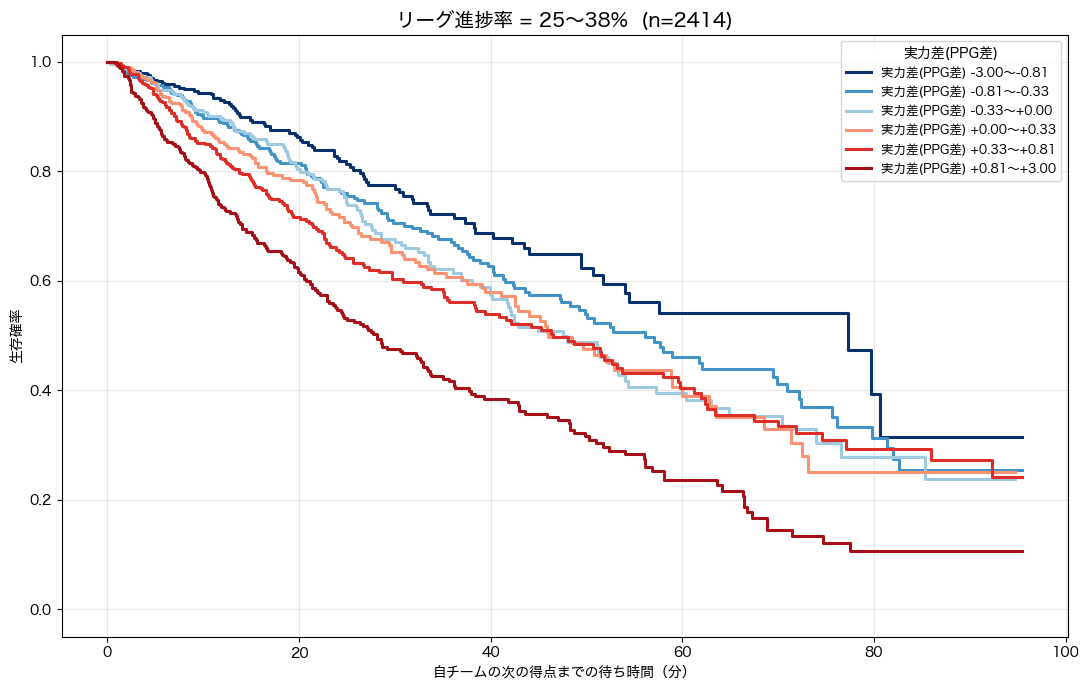

節（進捗率）= 25〜38%  (n=2414, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81       71.629085  2.597003e-17***  55.095930   
            -0.81〜-0.33       47.861424  4.574340e-12***  37.669574   
            -0.33〜+0.00       30.398591  3.517837e-08***  24.760736   
+0.00〜+0.33 +0.81〜+3.00       24.744012  6.547190e-07***  20.542621   
+0.33〜+0.81 +0.81〜+3.00       20.090117  7.387746e-06***  17.046434   
            -3.00〜-0.81       18.780335  1.466717e-05***  16.057050   
+0.00〜+0.33 -3.00〜-0.81       11.086361  8.696498e-04***  10.167278   
-0.33〜+0.00 -3.00〜-0.81        8.196136  4.197970e-03***   7.896093   
+0.33〜+0.81 -0.81〜-0.33        4.878068   2.720004e-02**   5.200247   
-0.81〜-0.33 -3.00〜-0.81        4.057549   4.397428e-02**   4.507196   
+0.00〜+0.33 -0.81〜-0.33        2.050934     1.521129e-01   2.716786   
+0.33〜+0.81 -0.33〜+0.00        1.675171     1.955674e-01   2.354262   
-0.33〜+0.00 -0.81〜-0.33        0.889164     3.457040e-01   1.532391   
+0.00〜+0.33 +0.33〜+0.81        0.655718     4.180757e-01   1.258164   
            -0.33〜+0.00        0.237913     6.257175e-01   0.676417   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  3.895505e-16***  
            -0.81〜-0.33  6.861510e-11***  
            -0.33〜+0.00  5.276755e-07***  
+0.00〜+0.33 +0.81〜+3.00  9.820784e-06***  
+0.33〜+0.81 +0.81〜+3.00  1.108162e-04***  
            -3.00〜-0.81  2.200076e-04***  
+0.00〜+0.33 -3.00〜-0.81   1.304475e-02**  
-0.33〜+0.00 -3.00〜-0.81    6.296954e-02*  
+0.33〜+0.81 -0.81〜-0.33     4.080007e-01  
-0.81〜-0.33 -3.00〜-0.81     6.596142e-01  
+0.00〜+0.33 -0.81〜-0.33     1.000000e+00  
+0.33〜+0.81 -0.33〜+0.00     1.000000e+00  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00  
+0.00〜+0.33 +0.33〜+0.81     1.000000e+00  
            -0.33〜+0.00     1.000000e+00

In [16]:
plot_km_single("25〜38%")

pairwise_logrank_table("25〜38%")

### 進捗率 38〜50%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

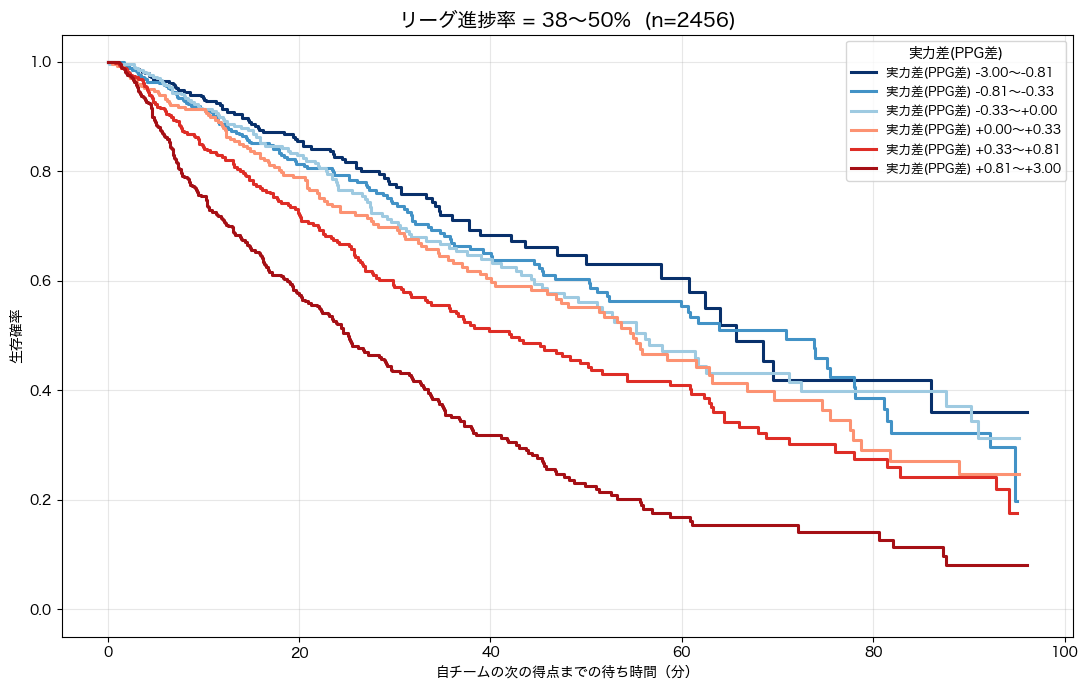

節（進捗率）= 38〜50%  (n=2456, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81      102.115768  5.237003e-24***  77.337533   
            -0.81〜-0.33       87.275085  9.443001e-21***  66.521245   
            -0.33〜+0.00       71.614008  2.616923e-17***  55.084906   
+0.00〜+0.33 +0.81〜+3.00       52.583220  4.123977e-13***  41.141029   
+0.33〜+0.81 +0.81〜+3.00       31.284185  2.228879e-08***  25.419106   
            -3.00〜-0.81       22.999381  1.620536e-06***  19.235098   
            -0.81〜-0.33       13.695409  2.149794e-04***  12.183514   
            -0.33〜+0.00        9.503964  2.050285e-03***   8.929960   
+0.00〜+0.33 -3.00〜-0.81        6.272998   1.225916e-02**   6.349996   
            +0.33〜+0.81        3.847532   4.981926e-02**   4.327153   
-0.33〜+0.00 -3.00〜-0.81        2.289733     1.302323e-01   2.940841   
+0.00〜+0.33 -0.81〜-0.33        2.201620     1.378658e-01   2.858664   
-0.81〜-0.33 -3.00〜-0.81        1.407196     2.355225e-01   2.086063   
+0.00〜+0.33 -0.33〜+0.00        1.062409     3.026664e-01   1.724199   
-0.33〜+0.00 -0.81〜-0.33        0.160606     6.885994e-01   0.538263   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  7.855505e-23***  
            -0.81〜-0.33  1.416450e-19***  
            -0.33〜+0.00  3.925385e-16***  
+0.00〜+0.33 +0.81〜+3.00  6.185966e-12***  
+0.33〜+0.81 +0.81〜+3.00  3.343319e-07***  
            -3.00〜-0.81  2.430803e-05***  
            -0.81〜-0.33  3.224691e-03***  
            -0.33〜+0.00   3.075427e-02**  
+0.00〜+0.33 -3.00〜-0.81     1.838874e-01  
            +0.33〜+0.81     7.472889e-01  
-0.33〜+0.00 -3.00〜-0.81     1.000000e+00  
+0.00〜+0.33 -0.81〜-0.33     1.000000e+00  
-0.81〜-0.33 -3.00〜-0.81     1.000000e+00  
+0.00〜+0.33 -0.33〜+0.00     1.000000e+00  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00

In [17]:
plot_km_single("38〜50%")

pairwise_logrank_table("38〜50%")

### 進捗率 50〜62%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

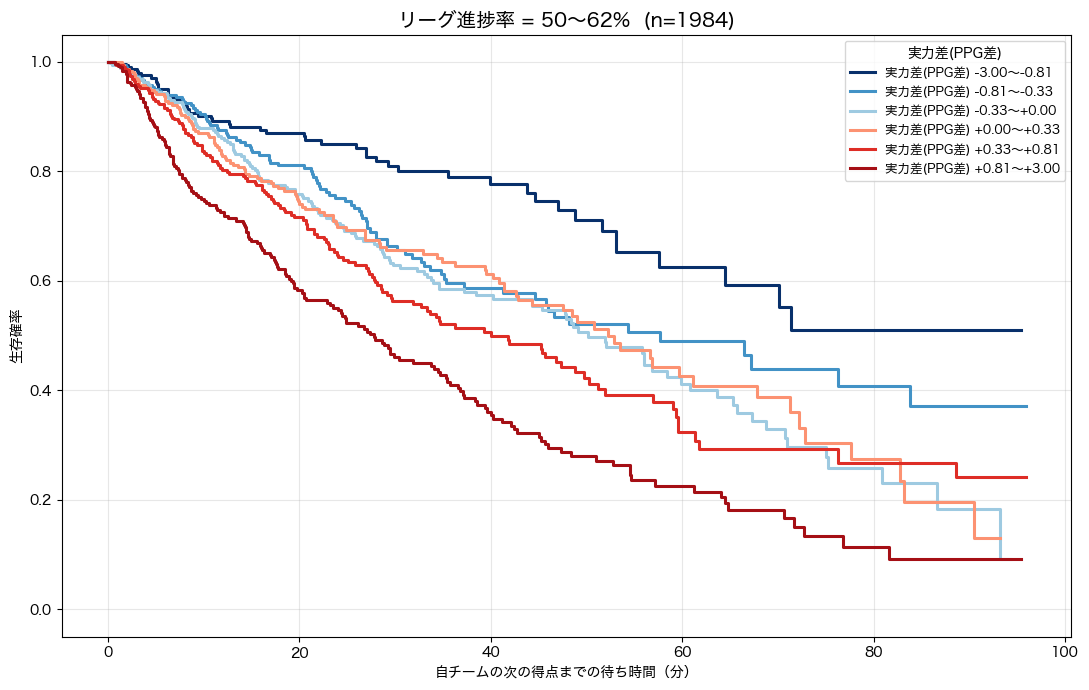

節（進捗率）= 50〜62%  (n=1984, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81       72.269869  1.876914e-17***  55.564415   
            -0.81〜-0.33       37.332928  9.958887e-10***  29.903296   
+0.33〜+0.81 -3.00〜-0.81       28.445779  9.635962e-08***  23.306996   
+0.00〜+0.33 +0.81〜+3.00       26.263269  2.979009e-07***  21.678664   
+0.81〜+3.00 -0.33〜+0.00       25.935268  3.530595e-07***  21.433585   
-0.33〜+0.00 -3.00〜-0.81       18.236289  1.951255e-05***  15.645238   
+0.00〜+0.33 -3.00〜-0.81       15.539953  8.077980e-05***  13.595646   
+0.33〜+0.81 +0.81〜+3.00       13.023951  3.075324e-04***  11.666974   
-0.81〜-0.33 -3.00〜-0.81        8.027626  4.606918e-03***   7.761982   
+0.33〜+0.81 -0.81〜-0.33        7.044932  7.948983e-03***   6.975014   
-0.33〜+0.00 -0.81〜-0.33        2.379900     1.229054e-01   3.024380   
+0.00〜+0.33 +0.33〜+0.81        2.123864     1.450203e-01   2.785674   
+0.33〜+0.81 -0.33〜+0.00        1.652608     1.986043e-01   2.332031   
+0.00〜+0.33 -0.81〜-0.33        1.581236     2.085828e-01   2.261308   
            -0.33〜+0.00        0.045818     8.305071e-01   0.267936   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  2.815371e-16***  
            -0.81〜-0.33  1.493833e-08***  
+0.33〜+0.81 -3.00〜-0.81  1.445394e-06***  
+0.00〜+0.33 +0.81〜+3.00  4.468514e-06***  
+0.81〜+3.00 -0.33〜+0.00  5.295892e-06***  
-0.33〜+0.00 -3.00〜-0.81  2.926883e-04***  
+0.00〜+0.33 -3.00〜-0.81  1.211697e-03***  
+0.33〜+0.81 +0.81〜+3.00  4.612985e-03***  
-0.81〜-0.33 -3.00〜-0.81    6.910377e-02*  
+0.33〜+0.81 -0.81〜-0.33     1.192347e-01  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00  
+0.00〜+0.33 +0.33〜+0.81     1.000000e+00  
+0.33〜+0.81 -0.33〜+0.00     1.000000e+00  
+0.00〜+0.33 -0.81〜-0.33     1.000000e+00  
            -0.33〜+0.00     1.000000e+00

In [18]:
plot_km_single("50〜62%")

pairwise_logrank_table("50〜62%")

### 進捗率 62〜75%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

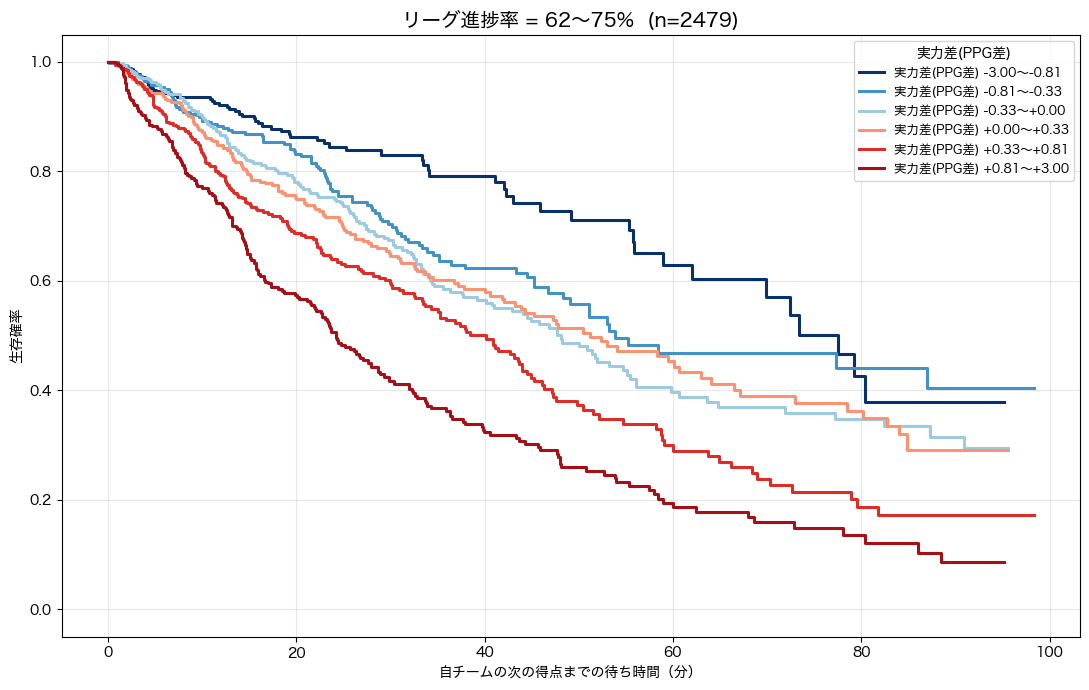

節（進捗率）= 62〜75%  (n=2479, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81       98.226665  3.731316e-23***  74.504662   
            -0.81〜-0.33       66.002835  4.502748e-16***  50.980044   
            -0.33〜+0.00       51.767030  6.249241e-13***  40.541384   
+0.33〜+0.81 -3.00〜-0.81       44.012256  3.263261e-11***  34.834895   
+0.00〜+0.33 +0.81〜+3.00       43.965952  3.341380e-11***  34.800765   
+0.33〜+0.81 -0.81〜-0.33       20.502451  5.955493e-06***  17.357348   
+0.00〜+0.33 -3.00〜-0.81       17.122730  3.504044e-05***  14.800620   
-0.33〜+0.00 -3.00〜-0.81       15.833620  6.916262e-05***  13.819648   
+0.33〜+0.81 +0.81〜+3.00       14.519325  1.387291e-04***  12.815442   
            -0.33〜+0.00       10.369379  1.281226e-03***   9.608259   
+0.00〜+0.33 +0.33〜+0.81        8.276815  4.015450e-03***   7.960223   
-0.81〜-0.33 -3.00〜-0.81        6.045472   1.394200e-02**   6.164418   
+0.00〜+0.33 -0.81〜-0.33        3.273200    7.042013e-02*   3.827868   
-0.33〜+0.00 -0.81〜-0.33        2.769291    9.608870e-02*   3.379489   
+0.00〜+0.33 -0.33〜+0.00        0.059712     8.069510e-01   0.309447   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  5.596974e-22***  
            -0.81〜-0.33  6.754121e-15***  
            -0.33〜+0.00  9.373862e-12***  
+0.33〜+0.81 -3.00〜-0.81  4.894892e-10***  
+0.00〜+0.33 +0.81〜+3.00  5.012070e-10***  
+0.33〜+0.81 -0.81〜-0.33  8.933239e-05***  
+0.00〜+0.33 -3.00〜-0.81  5.256066e-04***  
-0.33〜+0.00 -3.00〜-0.81  1.037439e-03***  
+0.33〜+0.81 +0.81〜+3.00  2.080936e-03***  
            -0.33〜+0.00   1.921839e-02**  
+0.00〜+0.33 +0.33〜+0.81    6.023174e-02*  
-0.81〜-0.33 -3.00〜-0.81     2.091300e-01  
+0.00〜+0.33 -0.81〜-0.33     1.000000e+00  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00  
+0.00〜+0.33 -0.33〜+0.00     1.000000e+00

In [19]:
plot_km_single("62〜75%")

pairwise_logrank_table("62〜75%")

### 進捗率 75〜88%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

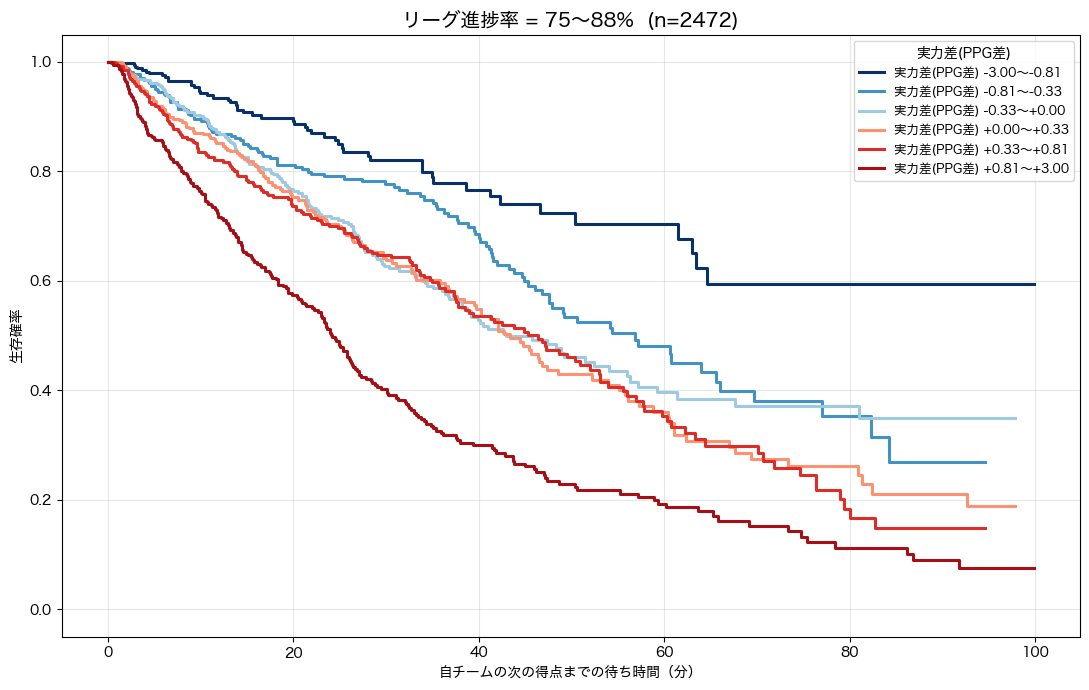

節（進捗率）= 75〜88%  (n=2472, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81      121.371927  3.168069e-28***  91.350383   
            -0.81〜-0.33       76.531713  2.167049e-18***  58.678974   
            -0.33〜+0.00       55.933614  7.495991e-14***  43.600874   
+0.33〜+0.81 -3.00〜-0.81       40.531090  1.935123e-10***  32.266855   
+0.00〜+0.33 +0.81〜+3.00       37.544801  8.933722e-10***  30.060020   
            -3.00〜-0.81       35.528389  2.513603e-09***  28.567596   
+0.33〜+0.81 +0.81〜+3.00       32.290818  1.327391e-08***  26.166831   
-0.33〜+0.00 -3.00〜-0.81       25.594379  4.212648e-07***  21.178769   
-0.81〜-0.33 -3.00〜-0.81       11.912808  5.574930e-04***  10.808759   
+0.33〜+0.81 -0.81〜-0.33       10.767523  1.032967e-03***   9.918991   
+0.00〜+0.33 -0.81〜-0.33        8.230857  4.118407e-03***   7.923698   
-0.33〜+0.00 -0.81〜-0.33        3.544184    5.975457e-02*   4.064807   
+0.33〜+0.81 -0.33〜+0.00        2.442986     1.180513e-01   3.082514   
+0.00〜+0.33 -0.33〜+0.00        1.332237     2.484077e-01   2.009218   
            +0.33〜+0.81        0.188079     6.645199e-01   0.589616   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  4.752103e-27***  
            -0.81〜-0.33  3.250574e-17***  
            -0.33〜+0.00  1.124399e-12***  
+0.33〜+0.81 -3.00〜-0.81  2.902685e-09***  
+0.00〜+0.33 +0.81〜+3.00  1.340058e-08***  
            -3.00〜-0.81  3.770405e-08***  
+0.33〜+0.81 +0.81〜+3.00  1.991086e-07***  
-0.33〜+0.00 -3.00〜-0.81  6.318972e-06***  
-0.81〜-0.33 -3.00〜-0.81  8.362394e-03***  
+0.33〜+0.81 -0.81〜-0.33   1.549450e-02**  
+0.00〜+0.33 -0.81〜-0.33    6.177611e-02*  
-0.33〜+0.00 -0.81〜-0.33     8.963185e-01  
+0.33〜+0.81 -0.33〜+0.00     1.000000e+00  
+0.00〜+0.33 -0.33〜+0.00     1.000000e+00  
            +0.33〜+0.81     1.000000e+00

In [20]:
plot_km_single("75〜88%")

pairwise_logrank_table("75〜88%")

### 進捗率 88〜100%

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

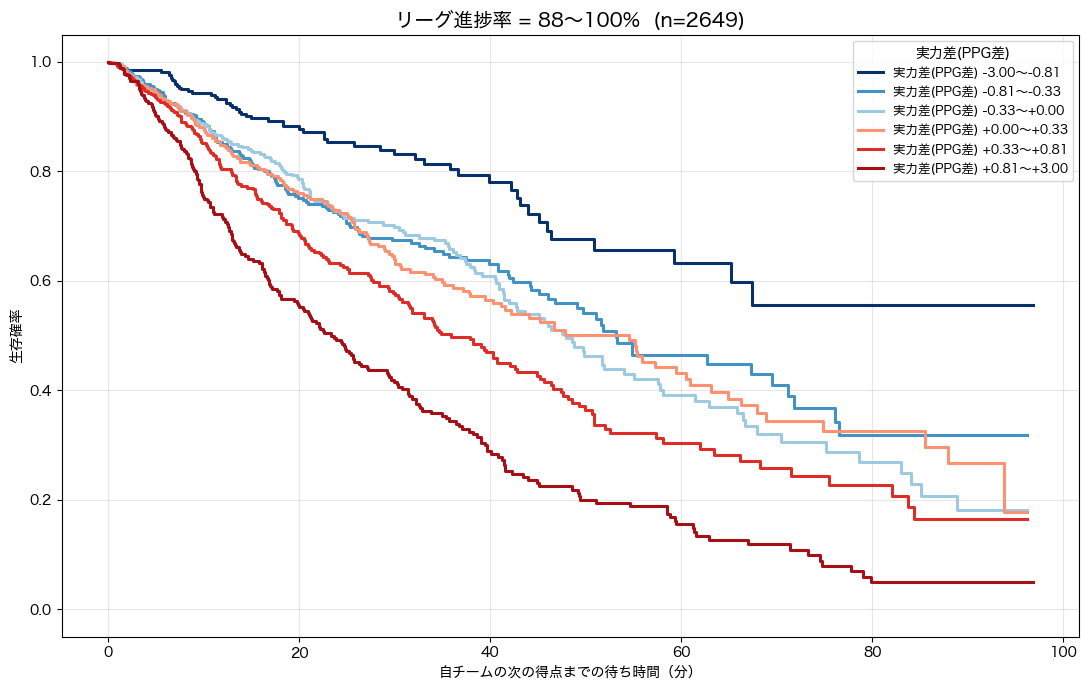

節（進捗率）= 88〜100%  (n=2649, 比較数=15)


test_statistic                p   -log2(p)  \
+0.81〜+3.00 -3.00〜-0.81      130.512924  3.164651e-30***  97.995796   
            -0.81〜-0.33       72.769177  1.457353e-17***  55.929428   
            -0.33〜+0.00       62.610148  2.519519e-15***  48.495773   
+0.00〜+0.33 +0.81〜+3.00       56.785211  4.861085e-14***  44.225715   
+0.33〜+0.81 -3.00〜-0.81       52.794295  3.703755e-13***  41.296077   
            +0.81〜+3.00       25.752045  3.882154e-07***  21.296639   
+0.00〜+0.33 -3.00〜-0.81       24.660654  6.836576e-07***  20.480223   
-0.33〜+0.00 -3.00〜-0.81       22.756873  1.838455e-06***  19.053075   
-0.81〜-0.33 -3.00〜-0.81       18.432782  1.760039e-05***  15.794033   
+0.33〜+0.81 -0.81〜-0.33       13.357299  2.574188e-04***  11.923595   
            -0.33〜+0.00        8.528770  3.495758e-03***   8.160179   
+0.00〜+0.33 +0.33〜+0.81        7.500168  6.169324e-03***   7.340672   
            -0.81〜-0.33        0.751715     3.859339e-01   1.373574   
-0.33〜+0.00 -0.81〜-0.33        0.563202     4.529728e-01   1.142504   
+0.00〜+0.33 -0.33〜+0.00        0.003466     9.530539e-01   0.069370   

                            p_bonferroni  
+0.81〜+3.00 -3.00〜-0.81  4.746977e-29***  
            -0.81〜-0.33  2.186029e-16***  
            -0.33〜+0.00  3.779278e-14***  
+0.00〜+0.33 +0.81〜+3.00  7.291627e-13***  
+0.33〜+0.81 -3.00〜-0.81  5.555632e-12***  
            +0.81〜+3.00  5.823230e-06***  
+0.00〜+0.33 -3.00〜-0.81  1.025486e-05***  
-0.33〜+0.00 -3.00〜-0.81  2.757682e-05***  
-0.81〜-0.33 -3.00〜-0.81  2.640059e-04***  
+0.33〜+0.81 -0.81〜-0.33  3.861282e-03***  
            -0.33〜+0.00    5.243637e-02*  
+0.00〜+0.33 +0.33〜+0.81    9.253986e-02*  
            -0.81〜-0.33     1.000000e+00  
-0.33〜+0.00 -0.81〜-0.33     1.000000e+00  
+0.00〜+0.33 -0.33〜+0.00     1.000000e+00

In [21]:
plot_km_single("88〜100%")

pairwise_logrank_table("88〜100%")